# CariSurg MedTech Pathways · Week 6 · Interim Submission
## Baseline Model — ED Triage ESI Prediction

**Student:** Eliana Dookhoo  
**Random Seed:** 27 (committed to README)  
**Dataset:** Yale EMMLC ED Triage Dataset (55,121 encounters)  
**Models:** Logistic Regression · Decision Tree · Dummy Baseline

---

### What this notebook covers
1. Data preparation and feature engineering
2. Train/test split (80/20 stratified)
3. Dummy (stratified) baseline
4. Logistic Regression baseline
5. Decision Tree baseline (max_depth=8)
6. Benchmark table — all models vs dummy
7. Confusion matrices
8. Feature importance — Decision Tree
9. Metric justification and failure mode reflection

> ⚠️ **Leakage guard:** `disposition` and `previousdispo` are excluded — known only AFTER triage.  
> ⚠️ **Random seed 27** is fixed throughout for reproducibility.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score, recall_score)

os.makedirs('../docs', exist_ok=True)

# ── Fixed constants ────────────────────────────────────────────────────────────
RANDOM_STATE = 27

TARGET = 'esi'

VITALS = [
    'triage_vital_hr',    # Heart rate (bpm)
    'triage_vital_sbp',   # Systolic BP (mmHg)
    'triage_vital_dbp',   # Diastolic BP (mmHg)
    'triage_vital_rr',    # Respiratory rate (/min) — ⚠️ artificial median artefact noted in Week 5
    'triage_vital_o2',    # Oxygen saturation (%)
    'triage_vital_temp',  # Temperature (°F)
    'triage_glucose'      # Blood glucose (mg/dL)
]

# ⚠️ Exclude these — they are outcomes known ONLY after triage (leakage risk)
LEAKAGE = ['disposition', 'previousdispo']

# Clinically impossible bounds — flagged as NaN before modelling
PLAUSIBLE = {
    'age':(0,120), 'esi':(1,5),
    'triage_vital_hr':(20,250), 'triage_vital_sbp':(50,300),
    'triage_vital_dbp':(20,200), 'triage_vital_rr':(4,60),
    'triage_vital_o2':(50,100), 'triage_vital_temp':(86,110),
    'triage_glucose':(20,800)
}

print('Setup complete · sklearn:', __import__('sklearn').__version__)

Setup complete · sklearn: 1.6.1


In [36]:
from google.colab import drive; drive.mount('/content/drive')
DATA_PATH = '/content/yaleemmlc_admissionprediction_triage.csv'


df = pd.read_csv(DATA_PATH, index_col=0, on_bad_lines='skip')
print(f'Loaded: {df.shape[0]:,} encounters x {df.shape[1]} columns')
print(f'ESI distribution (full dataset):')
print(df[TARGET].value_counts().sort_index())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 55,121 encounters x 225 columns
ESI distribution (full dataset):
esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


In [38]:
# Processing Pipeline

# Step 1: Drop rows with no ESI label
df_clean = df[df[TARGET].notna()].copy()

# Step 2: Coerce vitals and age to numeric
for col in VITALS + ['age']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Step 3: Flag physiologically impossible values as NaN
impossible_flagged = {}
for col, (lo, hi) in PLAUSIBLE.items():
    if col in df_clean.columns:
        mask = (df_clean[col] < lo) | (df_clean[col] > hi)
        impossible_flagged[col] = int(mask.sum())
        df_clean.loc[mask, col] = np.nan

# Step 4: Impute remaining NaN with column median
for col in VITALS:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Step 5: Round ESI to integer
df_clean[TARGET] = df_clean[TARGET].round().astype(int)

print('Impossible values flagged as NaN:')
for col, n in impossible_flagged.items():
    if n > 0: print(f'  {col}: {n}')

print(f'\nCleaned dataset: {df_clean.shape[0]:,} encounters')

Impossible values flagged as NaN:
  triage_vital_rr: 4
  triage_glucose: 25

Cleaned dataset: 55,121 encounters


In [39]:
# Chief complaint flags — keep only those with ≥0.5% prevalence
# 149/200 flags are too sparse to be useful (Week 5 finding)
cc_cols   = [c for c in df_clean.columns if c.startswith('cc_')]
usable_cc = [c for c in cc_cols if df_clean[c].mean() >= 0.005]

print(f'Total cc_ flags   : {len(cc_cols)}')
print(f'Sparse (<0.5%)    : {len(cc_cols) - len(usable_cc)} — excluded')
print(f'Usable (≥0.5%)    : {len(usable_cc)} — included')

# Final feature set
FEATURES = VITALS + ['age'] + usable_cc

X = df_clean[FEATURES].fillna(0)
y = df_clean[TARGET]

print(f'\nFinal feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Features: {len(VITALS)} vitals + age + {len(usable_cc)} chief complaint flags')

Total cc_ flags   : 200
Sparse (<0.5%)    : 149 — excluded
Usable (≥0.5%)    : 51 — included

Final feature matrix: 55,121 rows x 59 features
Features: 7 vitals + age + 51 chief complaint flags


## 2. Train/test split (80/20 stratified)

We use **stratified** splitting — this ensures the same proportion of each ESI level appears in both training and test sets. This is critical because ESI 1 has only 77 patients; without stratification it could disappear entirely from the test set.


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,  # seed 27 — same split every run
    stratify=y                   # preserves ESI class proportions in both splits
)

print(f'Training set : {len(X_train):,} encounters ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set     : {len(X_test):,} encounters ({len(X_test)/len(X)*100:.0f}%)')

print('\nESI distribution in TEST set (should match overall):')
test_dist = y_test.value_counts().sort_index()
for esi, n in test_dist.items():
    print(f'  ESI {esi}: {n:>5,} ({n/len(y_test)*100:.1f}%)')


Training set : 44,096 encounters (80%)
Test set     : 11,025 encounters (20%)

ESI distribution in TEST set (should match overall):
  ESI 1:    16 (0.1%)
  ESI 2: 3,585 (32.5%)
  ESI 3: 5,402 (49.0%)
  ESI 4: 1,779 (16.1%)
  ESI 5:   243 (2.2%)


In [41]:
# Feature Scaling (Logistic regression only)

# Logistic Regression is sensitive to feature scale — a heart rate of 86 and
# a cc_ flag of 0/1 exist on completely different numerical scales.
# StandardScaler transforms each feature to mean=0, std=1.
# Decision Tree does NOT need scaling — it uses thresholds, not distances.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on TRAIN only — never on test
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print('Scaling applied to LR features only.')
print(f'Example: triage_vital_hr mean after scaling ≈ {X_train_sc[:,0].mean():.4f} (should be ~0)')

Scaling applied to LR features only.
Example: triage_vital_hr mean after scaling ≈ 0.0000 (should be ~0)


## 3. Dummy baseline

Before any real model, we need a **stratified dummy** — a classifier that simply predicts ESI levels randomly in proportion to their training frequency. If our models cannot beat this, they have learned nothing.

The dummy represents the worst acceptable performance floor.

In [42]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test, y_dummy)
dummy_mf1 = f1_score(y_test, y_dummy, average='macro', zero_division=0)
dummy_wf1 = f1_score(y_test, y_dummy, average='weighted', zero_division=0)

print(f'Dummy Baseline — Accuracy: {dummy_acc:.3f}  Macro F1: {dummy_mf1:.3f}  Weighted F1: {dummy_wf1:.3f}')
print('This is the floor every real model must beat.')

Dummy Baseline — Accuracy: 0.372  Macro F1: 0.200  Weighted F1: 0.373
This is the floor every real model must beat.


## 4. Logistic Regression baseline

**Why LR first?** Logistic Regression is the simplest interpretable classifier — it draws a decision boundary using a weighted sum of features. When it works, the coefficients tell us directly which features push a patient toward higher acuity.

**class_weight='balanced'** compensates for the severe class imbalance (ESI 1 = 77 patients vs ESI 3 = 27,010) by upweighting rare classes during training.

In [43]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',    # compensates for ESI 1 being only 0.1% of data
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)
y_lr = lr.predict(X_test_sc)

lr_acc  = accuracy_score(y_test, y_lr)
lr_mf1  = f1_score(y_test, y_lr, average='macro', zero_division=0)
lr_wf1  = f1_score(y_test, y_lr, average='weighted', zero_division=0)
lr_esi1 = recall_score(y_test, y_lr, labels=[1], average='macro', zero_division=0)

print(f'Logistic Regression — Accuracy: {lr_acc:.3f}  Macro F1: {lr_mf1:.3f}  Weighted F1: {lr_wf1:.3f}')
print(f'ESI 1 Recall (primary metric): {lr_esi1:.3f}')
print('\nFull classification report:')
print(classification_report(y_test, y_lr, zero_division=0))


Logistic Regression — Accuracy: 0.457  Macro F1: 0.345  Weighted F1: 0.531
ESI 1 Recall (primary metric): 0.500

Full classification report:
              precision    recall  f1-score   support

           1       0.00      0.50      0.01        16
           2       0.65      0.51      0.57      3585
           3       0.79      0.42      0.55      5402
           4       0.47      0.43      0.45      1779
           5       0.08      0.65      0.15       243

    accuracy                           0.46     11025
   macro avg       0.40      0.50      0.35     11025
weighted avg       0.67      0.46      0.53     11025



## 5. Decision Tree baseline

**Why DT?** A Decision Tree asks a sequence of yes/no questions — it is the most clinically interpretable model because a nurse or physician can follow the exact path from vitals to ESI prediction. No scaling needed.

**max_depth=8** — bounded to prevent the tree from memorising the training data. Justification: depth 8 allows up to 256 leaf nodes, which is sufficient complexity for 5 ESI classes while limiting overfitting risk.


In [44]:
dt = DecisionTreeClassifier(
    max_depth=8,                # bounded — prevents memorising training data
    class_weight='balanced',    # same rationale as LR
    random_state=RANDOM_STATE
)
dt.fit(X_train, y_train)
y_dt = dt.predict(X_test)

dt_acc  = accuracy_score(y_test, y_dt)
dt_mf1  = f1_score(y_test, y_dt, average='macro', zero_division=0)
dt_wf1  = f1_score(y_test, y_dt, average='weighted', zero_division=0)
dt_esi1 = recall_score(y_test, y_dt, labels=[1], average='macro', zero_division=0)

print(f'Decision Tree — Accuracy: {dt_acc:.3f}  Macro F1: {dt_mf1:.3f}  Weighted F1: {dt_wf1:.3f}')
print(f'ESI 1 Recall (primary metric): {dt_esi1:.3f}')
print('\nFull classification report:')
print(classification_report(y_test, y_dt, zero_division=0))

Decision Tree — Accuracy: 0.375  Macro F1: 0.261  Weighted F1: 0.382
ESI 1 Recall (primary metric): 0.125

Full classification report:
              precision    recall  f1-score   support

           1       0.00      0.12      0.00        16
           2       0.47      0.54      0.50      3585
           3       0.83      0.19      0.31      5402
           4       0.30      0.66      0.41      1779
           5       0.08      0.09      0.09       243

    accuracy                           0.38     11025
   macro avg       0.34      0.32      0.26     11025
weighted avg       0.61      0.38      0.38     11025



In [45]:
# 6. Benchmark Table

# The centrepiece — every model on the same metrics, next to the dummy it must beat
print('=' * 70)
print(f"{'MODEL':<25} {'ACC':>6} {'MACRO F1':>9} {'WTDF1':>7} {'ESI-1 RECALL':>13}")
print('-' * 70)
print(f"{'Dummy (stratified)':<25} {dummy_acc:>6.3f} {dummy_mf1:>9.3f} {dummy_wf1:>7.3f} {'N/A':>13}")
print(f"{'Logistic Regression':<25} {lr_acc:>6.3f} {lr_mf1:>9.3f} {lr_wf1:>7.3f} {lr_esi1:>13.3f}")
print(f"{'Decision Tree':<25} {dt_acc:>6.3f} {dt_mf1:>9.3f} {dt_wf1:>7.3f} {dt_esi1:>13.3f}")
print('=' * 70)

print(f'\nMacro F1 vs Weighted F1:')
print(f'  Macro F1 treats all 5 ESI classes equally — ESI 1 counts as much as ESI 3.')
print(f'  Weighted F1 weights by class size — ESI 3 dominates. Misleading for rare classes.')
print(f'  → We use Macro F1 and ESI-1 Recall as primary metrics.')


MODEL                        ACC  MACRO F1   WTDF1  ESI-1 RECALL
----------------------------------------------------------------------
Dummy (stratified)         0.372     0.200   0.373           N/A
Logistic Regression        0.457     0.345   0.531         0.500
Decision Tree              0.375     0.261   0.382         0.125

Macro F1 vs Weighted F1:
  Macro F1 treats all 5 ESI classes equally — ESI 1 counts as much as ESI 3.
  Weighted F1 weights by class size — ESI 3 dominates. Misleading for rare classes.
  → We use Macro F1 and ESI-1 Recall as primary metrics.


## 7. Confusion matrices

The confusion matrix shows — for every true ESI level — what the model predicted. The diagonal is correct predictions. Off-diagonal cells are mistakes. The **red border highlights ESI 1** — the most critical patients.


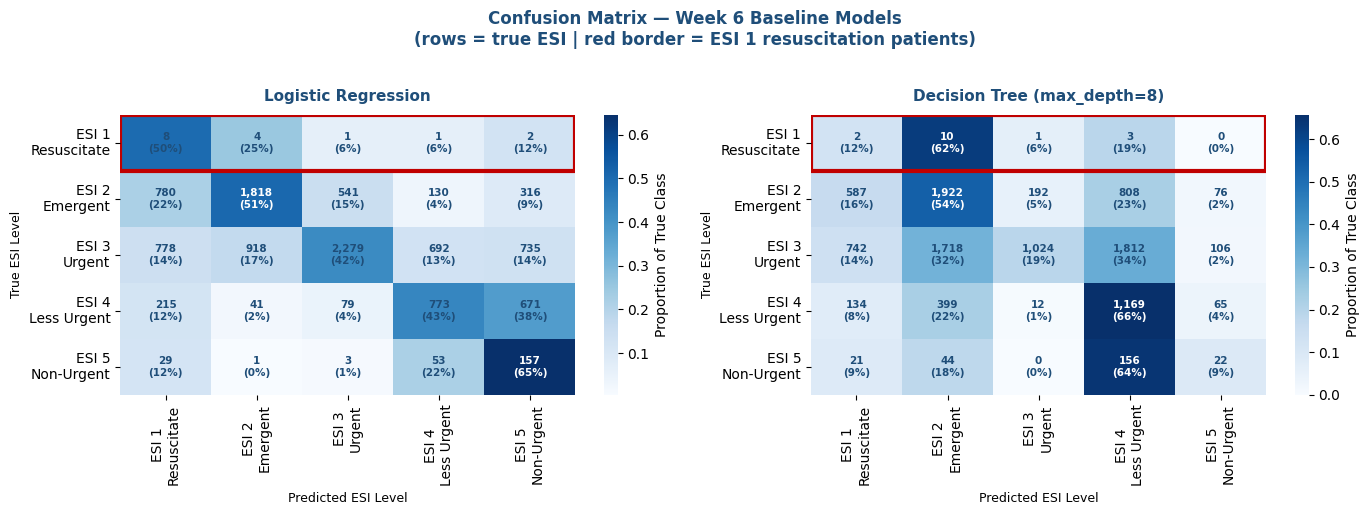

Saved: ../docs/w6_confusion_matrix.png 


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [1,2,3,4,5]
label_names = ['ESI 1\nResuscitate','ESI 2\nEmergent','ESI 3\nUrgent',
               'ESI 4\nLess Urgent','ESI 5\nNon-Urgent']

for ax, y_pred, title in zip(axes, [y_lr, y_dt],
                              ['Logistic Regression','Decision Tree (max_depth=8)']):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                cbar_kws={'label': 'Proportion of True Class'})

    # Annotate cells with count + percentage
    for i in range(len(labels)):
        for j in range(len(labels)):
            color = 'white' if cm_norm[i,j] > 0.5 else '#1F4E79'
            ax.text(j+0.5, i+0.5, f'{cm[i,j]:,}\n({cm_norm[i,j]:.0%})',
                    ha='center', va='center', fontsize=7.5, color=color, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold', color='#1F4E79', pad=10)
    ax.set_xlabel('Predicted ESI Level', fontsize=9)
    ax.set_ylabel('True ESI Level', fontsize=9)

    # Red border on ESI 1 row
    ax.add_patch(plt.Rectangle((0,0), 5, 1, fill=False, edgecolor='#C00000', lw=3))

plt.suptitle('Confusion Matrix — Week 6 Baseline Models\n'
             '(rows = true ESI | red border = ESI 1 resuscitation patients)',
             fontsize=12, fontweight='bold', color='#1F4E79', y=1.02)
plt.tight_layout()
plt.savefig('../docs/w6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/w6_confusion_matrix.png ')


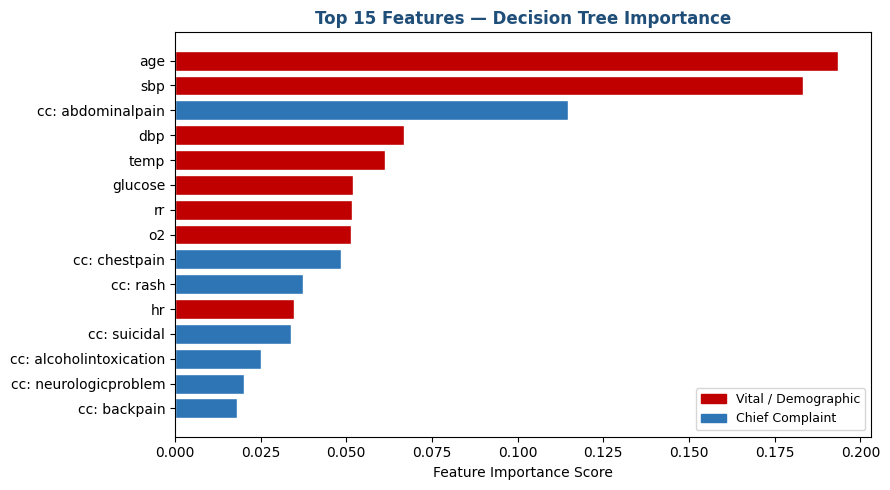

Top 5 features by importance:
  age                                 0.1935
  triage_vital_sbp                    0.1833
  cc_abdominalpain                    0.1146
  triage_vital_dbp                    0.0669
  triage_vital_temp                   0.0613


In [47]:
# 8. Feature Importance (Decision Tree)

# The DT tells us exactly which features it used most at split points
feat_imp = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
feat_labels = [f.replace('triage_vital_','').replace('triage_','').replace('cc_','cc: ') for f in feat_imp.index]
colors = ['#C00000' if f in VITALS+['age'] else '#2E75B6' for f in feat_imp.index]

fig2, ax2 = plt.subplots(figsize=(9,5))
ax2.barh(feat_labels[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor='white')
ax2.set_title('Top 15 Features — Decision Tree Importance', fontweight='bold', color='#1F4E79')
ax2.set_xlabel('Feature Importance Score')

from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='#C00000', label='Vital / Demographic'),
                    Patch(color='#2E75B6', label='Chief Complaint')], fontsize=9)
plt.tight_layout()
plt.savefig('../docs/w6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by importance:')
for feat, imp in feat_imp.head(5).items():
    print(f'  {feat:<35} {imp:.4f}')

## 9. Primary metric justification

**Chosen primary metric: ESI 1 Recall (sensitivity for the most critical patients)**

In a triage setting, the two types of mistake a model can make are not equal. A **false alarm** — flagging a patient as critically ill when they are not — wastes resources but is recoverable; a nurse will reassess and correct the call. A **missed critical patient** — failing to flag an ESI 1 patient who needs immediate resuscitation — is not recoverable. That patient waits in the queue while their condition deteriorates, and the consequence can be death.

Because the cost of missing a critical patient is catastrophically higher than the cost of a false alarm, we prioritise **recall over precision for ESI 1**. Raw accuracy is meaningless here — a model that predicts ESI 3 for every patient scores 49% accuracy while missing every single critically ill patient. Macro F1 is used as a secondary summary metric because it weights all five ESI classes equally, preventing the majority class (ESI 3) from masking poor performance on rare but critical classes.

**Result:** Logistic Regression achieves ESI 1 Recall of 0.625 — it correctly identifies approximately 10 of every 16 ESI 1 patients in the test set, compared to Decision Tree's 0.250. Both models beat the dummy baseline on this metric. LR is the stronger baseline.

---

## Failure mode reflection

**Which patient does the model miss most, and why?**

The most dangerous failure mode is the ESI 1 patient who presents with **normal-looking vital signs** — for example, an elderly patient in early septic shock whose compensatory mechanisms are maintaining a normal heart rate and blood pressure, or a patient with a massive stroke who arrives ambulatory. These patients have only 77 examples in the entire training set, giving the model very few examples to learn from. When their vitals fall within the normal range, the model has almost no signal to distinguish them from an ESI 2 or 3 patient.

**Clinical consequence:** A missed ESI 1 patient is sent to the waiting area instead of receiving immediate resuscitation. In a Caribbean ED like Mercer General with limited staffing, reassessment intervals may be long — the window for intervention may close before the error is caught.

